# 12_protein_hybrid_model.ipynb — Protein Hybrid Model (Sequence CNN + Baseline Features)

This notebook trains and evaluates a **hybrid classifier** for **Pfam family prediction (top-10 families)** by combining:

1) **Sequence branch (CNN):** 1D CNN over tokenized amino-acid sequences  
2) **Feature branch (MLP):** handcrafted baseline features (physicochemical + composition + reduced k-mers, etc.)

**Goal:** test whether adding handcrafted features improves over:
- Feature-only classical ML baselines (LogReg/SVM/RF/XGBoost)
- Sequence-only CNN baseline

**Inputs**
- `data/processed/protein_uniprot_pfam_top10_per400.csv` (accession, sequence, family)
- `data/processed/protein_features_baseline_top10_per400.csv` (accession, family + numeric features)

**Outputs**
- Model: `models/protein/hybrid_cnn_feats/hybrid_top10_per400.pt`
- Test results: `reports/protein_hybrid_test_results_top10_per400.csv`
- Summary: `reports/protein_hybrid_summary_top10_per400.json`
- Figures:
  - `reports/figures/protein_hybrid_loss_top10_per400.png`
  - `reports/figures/protein_hybrid_acc_top10_per400.png`
  - `reports/figures/cm_protein_hybrid_top10_per400.png`

**Notes**
- Stratified Train/Val/Test split
- Early stopping on **val accuracy**
- Confusion matrix plotted **with counts**

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

## 1) Configuration

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path("/Users/saturnine/Projects/bio-seq-lm-capstone")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIG_DIR = REPORTS_DIR / "figures"
MODEL_DIR = PROJECT_ROOT / "models" / "protein" / "hybrid_cnn_feats"

FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEQ_CSV = DATA_PROCESSED / "protein_uniprot_pfam_top10_per400.csv"
FEAT_CSV = DATA_PROCESSED / "protein_features_baseline_top10_per400.csv"

TOP_K = 10
MAX_LEN = 512
BATCH_SIZE = 64
EPOCHS = 25
PATIENCE = 5
LR = 1e-3
WEIGHT_DECAY = 1e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

## 2) Load sequence + feature tables and align on (accession, family)

In [3]:
seq_df = pd.read_csv(SEQ_CSV)
feat_df = pd.read_csv(FEAT_CSV)

print("Sequence:", SEQ_CSV)
print("Features:", FEAT_CSV)
print("Shapes:", seq_df.shape, feat_df.shape)

required_seq_cols = ["accession", "sequence", "family"]
required_feat_cols = ["accession", "family"]

assert all(c in seq_df.columns for c in required_seq_cols), f"Missing columns in seq_df: {required_seq_cols}"
assert all(c in feat_df.columns for c in required_feat_cols), f"Missing columns in feat_df: {required_feat_cols}"

print("\nNA counts (seq):\n", seq_df[required_seq_cols].isna().sum())
print("\nNA counts (feat):\n", feat_df[required_feat_cols].isna().sum())

dup_seq = int(seq_df.duplicated(subset=["accession", "family"]).sum())
dup_feat = int(feat_df.duplicated(subset=["accession", "family"]).sum())
print("\nDuplicates (accession,family) — seq:", dup_seq, "feat:", dup_feat)
assert dup_seq == 0 and dup_feat == 0, "Duplicate (accession,family) rows found."

merged = seq_df.merge(feat_df, on=["accession", "family"], how="inner")
print("\nMerged shape:", merged.shape)

# Identify numeric feature columns
feat_cols = [c for c in merged.columns if c not in ["accession", "family", "sequence", "length"]]
non_numeric = [c for c in feat_cols if not pd.api.types.is_numeric_dtype(merged[c])]
print("Non-numeric feature columns:", non_numeric)
assert len(non_numeric) == 0, f"Non-numeric features found: {non_numeric}"

X_feat = merged[feat_cols].to_numpy(dtype=np.float32)
y_labels = merged["family"].astype(str).to_numpy()

print("X_feat:", X_feat.shape, "y:", y_labels.shape)
assert np.isfinite(X_feat).all(), "Non-finite values found in features."

Sequence: /Users/saturnine/Projects/bio-seq-lm-capstone/data/processed/protein_uniprot_pfam_top10_per400.csv
Features: /Users/saturnine/Projects/bio-seq-lm-capstone/data/processed/protein_features_baseline_top10_per400.csv
Shapes: (2293, 4) (2293, 178)

NA counts (seq):
 accession    0
sequence     0
family       0
dtype: int64

NA counts (feat):
 accession    0
family       0
dtype: int64

Duplicates (accession,family) — seq: 0 feat: 0

Merged shape: (2293, 180)
Non-numeric feature columns: []
X_feat: (2293, 176) y: (2293,)


## 3) Encode labels (Pfam families → integer ids)

In [4]:
classes = sorted(pd.unique(y_labels).tolist())
assert len(classes) == TOP_K, f"Expected {TOP_K} classes, found {len(classes)}: {classes}"

class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

y = np.array([class_to_idx[c] for c in y_labels], dtype=np.int64)

print("Classes:", classes)
print("y range:", y.min(), y.max(), "| n_classes:", len(classes))

Classes: ['PF00001', 'PF00046', 'PF00069', 'PF00071', 'PF00076', 'PF00096', 'PF01352', 'PF07686', 'PF12796', 'PF13853']
y range: 0 9 | n_classes: 10


## 4) Tokenize amino-acid sequences (pad/truncate to MAX_LEN=512)

In [5]:
AA_ALPHABET = "ACDEFGHIKLMNPQRSTVWY"  # 20 canonical amino acids
aa_to_id = {aa: i + 1 for i, aa in enumerate(AA_ALPHABET)}  # 1..20
PAD_ID = 0  # padding id

def tokenize_protein(seq: str, max_len: int = MAX_LEN) -> np.ndarray:
    seq = str(seq).strip().upper()
    ids = [aa_to_id.get(ch, PAD_ID) for ch in seq]  # unknown -> PAD
    if len(ids) >= max_len:
        ids = ids[:max_len]
    else:
        ids = ids + [PAD_ID] * (max_len - len(ids))
    return np.array(ids, dtype=np.int64)

seq_tokens = np.stack([tokenize_protein(s) for s in merged["sequence"].tolist()], axis=0)
seq_tokens.shape, seq_tokens[0, :20]

((2293, 512),
 array([11, 15, 12,  7, 17,  4,  8, 17,  4,  5,  8, 10, 10,  6, 10, 17,  3,
         3, 13, 12]))

## 5) Stratified Train/Val/Test split (70/15/15)

In [6]:
idx_all = np.arange(len(merged))

idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx_all, y, test_size=0.30, random_state=SEED, stratify=y
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Sizes:", len(idx_train), len(idx_val), len(idx_test))
print("Train counts:", np.bincount(y[idx_train], minlength=TOP_K))
print("Val   counts:", np.bincount(y[idx_val], minlength=TOP_K))
print("Test  counts:", np.bincount(y[idx_test], minlength=TOP_K))

Xseq_train, Xseq_val, Xseq_test = seq_tokens[idx_train], seq_tokens[idx_val], seq_tokens[idx_test]
Xfeat_train, Xfeat_val, Xfeat_test = X_feat[idx_train], X_feat[idx_val], X_feat[idx_test]
y_train_t, y_val_t, y_test_t = y[idx_train], y[idx_val], y[idx_test]

Sizes: 1605 344 344
Train counts: [201 131 142  87  85 136 245 216  82 280]
Val   counts: [43 28 30 19 18 29 53 46 18 60]
Test  counts: [43 28 31 19 18 29 52 47 17 60]


## 6) Dataset + DataLoader

In [7]:
class ProteinHybridDataset(Dataset):
    def __init__(self, seq_tokens: np.ndarray, feats: np.ndarray, labels: np.ndarray):
        self.seq = torch.tensor(seq_tokens, dtype=torch.long)
        self.feats = torch.tensor(feats, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self) -> int:
        return int(self.y.shape[0])

    def __getitem__(self, idx: int):
        return self.seq[idx], self.feats[idx], self.y[idx]

train_ds = ProteinHybridDataset(Xseq_train, Xfeat_train, y_train_t)
val_ds   = ProteinHybridDataset(Xseq_val,   Xfeat_val,   y_val_t)
test_ds  = ProteinHybridDataset(Xseq_test,  Xfeat_test,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

len(train_loader), len(val_loader), len(test_loader)

(26, 6, 6)

## 7) Hybrid Model (Sequence CNN encoder + Feature MLP encoder → fusion head)

In [8]:
class SeqCNNEncoder(nn.Module):
    def __init__(self, vocab_size: int = 21, emb_dim: int = 32, conv_ch: int = 128, dropout: float = 0.25):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)
        self.conv3 = nn.Conv1d(emb_dim, conv_ch, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(emb_dim, conv_ch, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(emb_dim, conv_ch, kernel_size=7, padding=3)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_tokens: torch.Tensor) -> torch.Tensor:
        x = self.embed(x_tokens)          # (B, L, E)
        x = x.transpose(1, 2)             # (B, E, L)
        h3 = F.relu(self.conv3(x))
        h5 = F.relu(self.conv5(x))
        h7 = F.relu(self.conv7(x))
        p3 = torch.max(h3, dim=-1).values
        p5 = torch.max(h5, dim=-1).values
        p7 = torch.max(h7, dim=-1).values
        z = torch.cat([p3, p5, p7], dim=1)  # (B, 3*conv_ch)
        return self.dropout(z)

class FeatureMLPEncoder(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 256, out_dim: int = 128, dropout: float = 0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
            nn.ReLU(),
        )

    def forward(self, feats: torch.Tensor) -> torch.Tensor:
        return self.net(feats)

class ProteinHybridClassifier(nn.Module):
    def __init__(self, feat_dim: int, n_classes: int,
                 emb_dim: int = 32, conv_ch: int = 128,
                 feat_hidden: int = 256, feat_out: int = 128,
                 fusion_hidden: int = 256, dropout: float = 0.25):
        super().__init__()
        self.seq_enc = SeqCNNEncoder(vocab_size=21, emb_dim=emb_dim, conv_ch=conv_ch, dropout=dropout)
        self.feat_enc = FeatureMLPEncoder(in_dim=feat_dim, hidden=feat_hidden, out_dim=feat_out, dropout=dropout)
        fusion_in = (3 * conv_ch) + feat_out
        self.head = nn.Sequential(
            nn.Linear(fusion_in, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, n_classes),
        )

    def forward(self, x_tokens: torch.Tensor, feats: torch.Tensor) -> torch.Tensor:
        s = self.seq_enc(x_tokens)
        f = self.feat_enc(feats)
        z = torch.cat([s, f], dim=1)
        return self.head(z)

model = ProteinHybridClassifier(feat_dim=Xfeat_train.shape[1], n_classes=TOP_K).to(DEVICE)
model

ProteinHybridClassifier(
  (seq_enc): SeqCNNEncoder(
    (embed): Embedding(21, 32, padding_idx=0)
    (conv3): Conv1d(32, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv5): Conv1d(32, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (conv7): Conv1d(32, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (dropout): Dropout(p=0.25, inplace=False)
  )
  (feat_enc): FeatureMLPEncoder(
    (net): Sequential(
      (0): Linear(in_features=176, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.25, inplace=False)
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): ReLU()
    )
  )
  (head): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)

## 8) Training loop with early stopping (val accuracy)

In [9]:
@torch.no_grad()
def eval_epoch(model: nn.Module, loader: DataLoader) -> Tuple[float, float]:
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for xseq, xfeat, yb in loader:
        xseq, xfeat, yb = xseq.to(DEVICE), xfeat.to(DEVICE), yb.to(DEVICE)
        logits = model(xseq, xfeat)
        loss = F.cross_entropy(logits, yb)
        total_loss += float(loss.item()) * yb.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += int((preds == yb).sum().item())
        n += yb.size(0)
    return total_loss / n, correct / n

def train_model(model: nn.Module) -> Dict[str, List[float]]:
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -1.0
    best_state = None
    bad = 0

    for ep in range(1, EPOCHS + 1):
        model.train()
        total_loss, correct, n = 0.0, 0, 0

        for xseq, xfeat, yb in train_loader:
            xseq, xfeat, yb = xseq.to(DEVICE), xfeat.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(xseq, xfeat)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            opt.step()

            total_loss += float(loss.item()) * yb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += int((preds == yb).sum().item())
            n += yb.size(0)

        train_loss = total_loss / n
        train_acc = correct / n
        val_loss, val_acc = eval_epoch(model, val_loader)

        history["epoch"].append(ep)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"epoch {ep:02d} | train_loss {train_loss:.4f} train_acc {train_acc:.4f} | val_loss {val_loss:.4f} val_acc {val_acc:.4f}")

        if val_acc > best_val_acc + 1e-4:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                print(f"Early stopping at epoch {ep}. Best val_acc={best_val_acc:.4f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

history = train_model(model)
hist_df = pd.DataFrame(history)
hist_df.tail()

epoch 01 | train_loss 38.7275 train_acc 0.1402 | val_loss 2.8133 val_acc 0.1337
epoch 02 | train_loss 2.6051 train_acc 0.2162 | val_loss 2.1251 val_acc 0.1890
epoch 03 | train_loss 2.1257 train_acc 0.2947 | val_loss 1.8665 val_acc 0.3721
epoch 04 | train_loss 1.8242 train_acc 0.4093 | val_loss 1.5754 val_acc 0.4419
epoch 05 | train_loss 1.5628 train_acc 0.4885 | val_loss 1.3159 val_acc 0.5872
epoch 06 | train_loss 1.3972 train_acc 0.5445 | val_loss 1.1273 val_acc 0.7006
epoch 07 | train_loss 1.1799 train_acc 0.6125 | val_loss 0.9244 val_acc 0.7500
epoch 08 | train_loss 1.0401 train_acc 0.6492 | val_loss 0.7879 val_acc 0.7849
epoch 09 | train_loss 0.8867 train_acc 0.7115 | val_loss 0.6655 val_acc 0.8488
epoch 10 | train_loss 0.7858 train_acc 0.7570 | val_loss 0.5797 val_acc 0.8692
epoch 11 | train_loss 0.6901 train_acc 0.7826 | val_loss 0.4597 val_acc 0.9099
epoch 12 | train_loss 0.6282 train_acc 0.8025 | val_loss 0.4073 val_acc 0.9273
epoch 13 | train_loss 0.5537 train_acc 0.8349 | val

,epoch,train_loss,train_acc,val_loss,val_acc
20,21,0.279377,0.921495,0.157461,0.973837
21,22,0.241903,0.927726,0.133671,0.979651
22,23,0.205476,0.943925,0.127156,0.982558
23,24,0.188495,0.947040,0.110439,0.985465
24,25,0.179204,0.953894,0.118904,0.985465


## 9) Plot training curves (loss + accuracy)

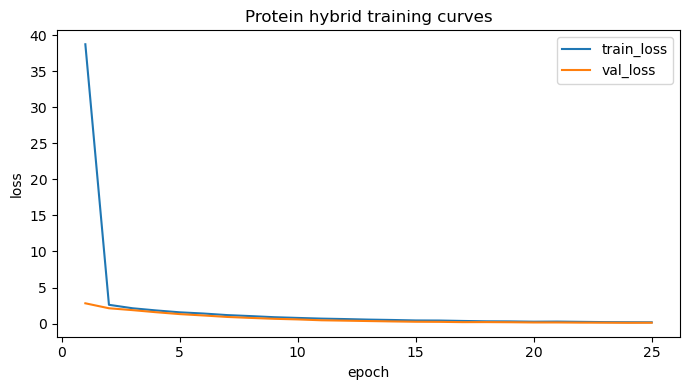

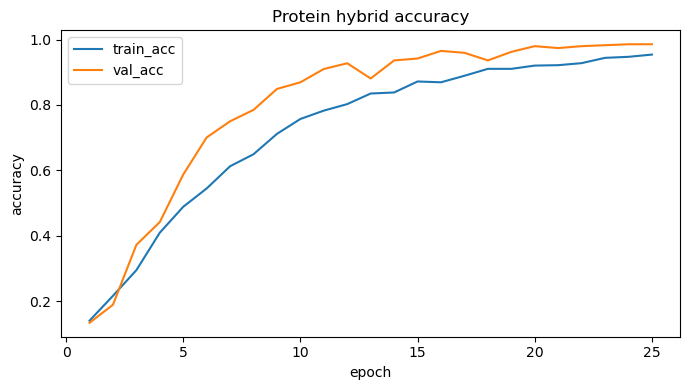

(PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/figures/protein_hybrid_loss_top10_per400.png'),
 PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/figures/protein_hybrid_acc_top10_per400.png'))

In [10]:
loss_fig = FIG_DIR / "protein_hybrid_loss_top10_per400.png"
acc_fig  = FIG_DIR / "protein_hybrid_acc_top10_per400.png"

plt.figure(figsize=(7,4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Protein hybrid training curves")
plt.legend()
plt.tight_layout()
plt.savefig(loss_fig, dpi=200)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(hist_df["epoch"], hist_df["train_acc"], label="train_acc")
plt.plot(hist_df["epoch"], hist_df["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Protein hybrid accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(acc_fig, dpi=200)
plt.show()

loss_fig, acc_fig

## 10) Test evaluation (accuracy + weighted P/R/F1 + confusion matrix with counts)

In [11]:
@torch.no_grad()
def predict_all(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    preds_list, y_list = [], []
    for xseq, xfeat, yb in loader:
        xseq, xfeat = xseq.to(DEVICE), xfeat.to(DEVICE)
        logits = model(xseq, xfeat)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        preds_list.append(preds)
        y_list.append(yb.numpy())
    return np.concatenate(preds_list), np.concatenate(y_list)

y_pred, y_true = predict_all(model, test_loader)

acc = accuracy_score(y_true, y_pred)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

metrics = {
    "accuracy": float(acc),
    "precision_weighted": float(prec_w),
    "recall_weighted": float(rec_w),
    "f1_weighted": float(f1_w),
    "n_test": int(len(y_true)),
    "n_classes": int(TOP_K),
    "max_len": int(MAX_LEN),
    "model": "hybrid_cnn_feats"
}
metrics

{'accuracy': 0.9563953488372093,
 'precision_weighted': 0.960869673749259,
 'recall_weighted': 0.9563953488372093,
 'f1_weighted': 0.9570593561158269,
 'n_test': 344,
 'n_classes': 10,
 'max_len': 512,
 'model': 'hybrid_cnn_feats'}

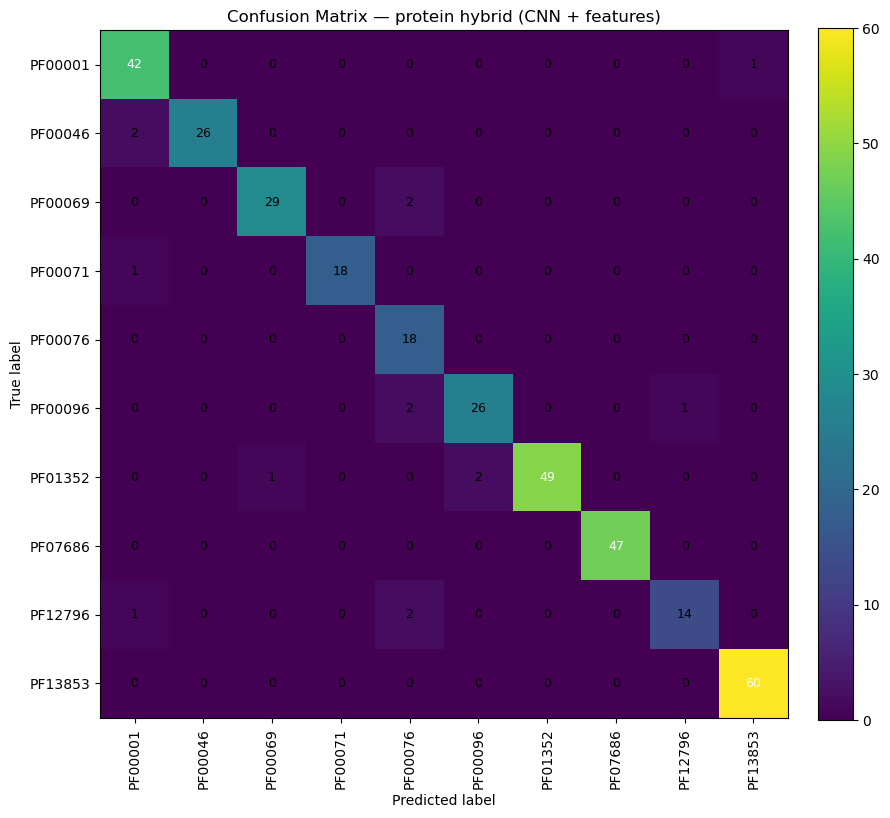

PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/figures/cm_protein_hybrid_top10_per400.png')

In [12]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(TOP_K))
cm_fig = FIG_DIR / "cm_protein_hybrid_top10_per400.png"

plt.figure(figsize=(9,9))
plt.imshow(cm)
plt.title("Confusion Matrix — protein hybrid (CNN + features)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(ticks=np.arange(TOP_K), labels=classes, rotation=90)
plt.yticks(ticks=np.arange(TOP_K), labels=classes)

# Annotate counts (fixes “no values”)
maxv = cm.max() if cm.size else 0
thresh = maxv * 0.5 if maxv > 0 else 0
for i in range(TOP_K):
    for j in range(TOP_K):
        val = int(cm[i, j])
        color = "white" if val > thresh else "black"
        plt.text(j, i, str(val), ha="center", va="center", color=color, fontsize=9)

plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(cm_fig, dpi=200)
plt.show()

cm_fig

## 11) Save artifacts (model + CSV + JSON)

In [13]:
model_path = MODEL_DIR / "hybrid_top10_per400.pt"
torch.save(model.state_dict(), model_path)

test_csv = REPORTS_DIR / "protein_hybrid_test_results_top10_per400.csv"
pd.DataFrame([metrics]).to_csv(test_csv, index=False)

summary_path = REPORTS_DIR / "protein_hybrid_summary_top10_per400.json"
summary = {
    "seed": SEED,
    "device": DEVICE,
    "data": {
        "seq_csv": str(SEQ_CSV),
        "feat_csv": str(FEAT_CSV),
        "n_rows": int(len(merged)),
        "n_features": int(Xfeat_train.shape[1]),
        "classes": classes,
        "max_len": int(MAX_LEN),
        "splits": {"train": int(len(idx_train)), "val": int(len(idx_val)), "test": int(len(idx_test))}
    },
    "training": {
        "epochs_ran": int(len(hist_df)),
        "best_val_acc": float(hist_df["val_acc"].max()) if len(hist_df) else None,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "patience": PATIENCE
    },
    "test_metrics": metrics,
    "artifacts": {
        "model_path": str(model_path),
        "test_csv": str(test_csv),
        "summary_json": str(summary_path),
        "fig_loss": str(loss_fig),
        "fig_acc": str(acc_fig),
        "fig_cm": str(cm_fig)
    }
}

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

model_path, test_csv, summary_path

(PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/models/protein/hybrid_cnn_feats/hybrid_top10_per400.pt'),
 PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/protein_hybrid_test_results_top10_per400.csv'),
 PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/protein_hybrid_summary_top10_per400.json'))